# Action Recognition
 Foundations of Machine Learning SS26    
 Group 11 - G. Sammet, M. Schlichting
### Dataset 
- RGB videos
    - ca 2 seconds long
    - resolution 1920x1080
- ca. 900 videos per action
- 4 actions: waving, capitulate, cross arms and clapping

    **Aquisition:**    
    We contacted ROSE Lab to get permission for the download. Due to hardware limits we downloaded the zip files in batched and ran the ``process_NTU.py`` to extract only the action classes we wanted.

    *The research in this project used the NTU RGB+D (or NTU RGB+D 120) Action Recognition Dataset made available by the ROSE Lab at the Nanyang Technological University, Singapore.*

    ROSE Lab. Action recognition datasets: “NTU RGB+D” dataset and “NTU RGB+D 120” dataset [Dataset]. https://rose1.ntu.edu.sg/dataset/actionRecognition/  

### Imports

In [46]:
from pathlib import Path
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import accuracy_score, classification_report

import random
from PIL import Image
import matplotlib.pyplot as plt
import string
import numpy as np
import os
import pandas as pd

import optuna
from IPython.display import Video, display
import cv2

## Experiment 1
### Model 1: Simple One-Frame-Model
single frame -> pre-trained ResNet18 -> custom classifier output layer

### Load ResNet18 Model & Dataset

In [3]:
# load pretrained model
weights = ResNet18_Weights.DEFAULT
resnet_model = resnet18(weights=weights)

# modify last layer to 4 classes
resnet_model.fc = torch.nn.Linear(resnet_model.fc.in_features, 4)

# define loss function and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(resnet_model.fc.parameters(), lr=0.001, momentum=0.9)

# define transformations for our dataset
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### Training Loop

In [4]:
# training loop 
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    # determine device
    device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

    for epoch in range(num_epochs):
        # training mode
        model.train()

        running_loss = 0.0
        running_corrects = 0

        # iterate training data loader
        for inputs, labels in train_loader:
            # put to device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # reset gradients 
            optimizer.zero_grad()

            # forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            # backward pass
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        # epoch training loss and accuracy 
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = running_corrects.float() / len(train_loader.dataset)


        ## Evaluation
        model.eval()
        running_loss = 0.0
        running_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # forward pass
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

        # validation loss and accuracy 
        val_loss = running_loss / len(val_loader.dataset)
        val_acc = running_corrects.float() / len(val_loader.dataset)

        print(f'Epoch [{epoch+1}/{num_epochs}], train loss: {train_loss:.4f}, train acc: {train_acc:.4f}, val loss: {val_loss:.4f}, val acc: {val_acc:.4f} \n')

In [5]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model_three_quarter = resnet_model.to(device)
# load data and transform
output_dir = Path("data/three_quarter_frame")  
train_dataset = ImageFolder((str(output_dir / "train")), transform=transform)
val_dataset = ImageFolder((str(output_dir / "val")), transform=transform)
test_dataset = ImageFolder((str(output_dir/ "test")), transform=transform)

train_loader_three_quarter = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader_three_quarter = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader_three_quarter = DataLoader(test_dataset, batch_size=32, shuffle=False)

if False: # set to True to train model 
    # train model
    train(model_three_quarter, train_loader_three_quarter, val_loader_three_quarter, criterion, optimizer, num_epochs=10)

    # save checkpoint of model
    checkpoint = {
        "model_three_quarter_state_dict": model_three_quarter.state_dict(),
        "optimizer_model_three_quarter_state_dict": optimizer.state_dict(),
        "epoch": 10,
    }

    torch.save(
        checkpoint,
        "checkpoints/model_three_quarter_checkpoint.pth"
    )

### Evaluation Function

In [6]:
def evaluate_model(model, test_loader, device):
    # evaluation mode
    model.eval()

    # Initialize dictionaries to store correct and total predictions
    correct_pred = {classname: 0 for classname in test_loader.dataset.classes}
    total_pred = {classname: 0 for classname in test_loader.dataset.classes}

    # track labels and predictions
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in test_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            # forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            # collect preds and labels
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

            # update correct and total preds
            for label, prediction in zip(labels, preds):
                classname = test_loader.dataset.classes[label]
                if label == prediction:
                    correct_pred[classname] += 1
                total_pred[classname] += 1

    # accuracy per class
    precision_per_class = {classname: correct_pred[classname] / total_pred[classname] if total_pred[classname] > 0 else 0
                          for classname in test_loader.dataset.classes}

    # overall accuracy
    overall_accuracy = accuracy_score(all_labels, all_preds)

    print("Precision per class:")
    for classname, accuracy in precision_per_class.items():
        print(f"{classname}: {accuracy:.4f}")
    print(f"Overall Accuracy: {overall_accuracy:.4f}")

    return precision_per_class, overall_accuracy

In [7]:
# load model
checkpoint = torch.load("checkpoints/model_three_quarter_checkpoint.pth",map_location=device)

model_three_quarter.load_state_dict(checkpoint["model_three_quarter_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_model_three_quarter_state_dict"])
model_three_quarter.to(device)

#evaluate
acc_classes_three_quarter, acc_total_three_quarter = evaluate_model(model_three_quarter, test_loader_three_quarter, device)

Precision per class:
class1: 0.9861
class2: 0.3566
class3: 0.7692
class4: 0.5455
Overall Accuracy: 0.6649


## Experiment 2: Three-Models-Approach
3 frames per video -> one model per frame type -> average over class predictions -> classification

#### Model 2: Middle-Frame-Model

In [8]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.SGD(resnet_model.fc.parameters(), lr=0.001, momentum=0.9)

# load datat for middle frame
output_dir = Path("data/middle_frame")  
train_dataset = ImageFolder((str(output_dir / "train")), transform=transform)
val_dataset = ImageFolder((str(output_dir / "val")), transform=transform)
test_dataset = ImageFolder((str(output_dir/ "test")), transform=transform)

train_loader_middle = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader_middle = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader_middle = DataLoader(test_dataset, batch_size=32, shuffle=False)

# train model 2
model_middle = resnet_model.to(device)

# set True to train model
if False:
    train(model_middle, train_loader_middle, val_loader_middle, criterion, optimizer, num_epochs=10)

    # save checkpoint of model
    checkpoint = {
        "model_middle_state_dict": model_middle.state_dict(),
        "optimizer_middle_state_dict": optimizer.state_dict(),
        "epoch": 10,
    }

    torch.save(
        checkpoint,
        "checkpoints/model_middle_checkpoint.pth"
    )

In [9]:
# load model
checkpoint = torch.load("checkpoints/model_middle_checkpoint.pth",map_location=device)

model_middle.load_state_dict(checkpoint["model_middle_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_middle_state_dict"])
model_middle.to(device)

#evaluate
acc_classes_middle, acc_total_middle = evaluate_model(model_middle, test_loader_middle, device)

Precision per class:
class1: 0.9861
class2: 0.6154
class3: 0.7203
class4: 0.3846
Overall Accuracy: 0.6771


#### Model 3: End-Frame-Model

In [10]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.SGD(resnet_model.fc.parameters(), lr=0.001, momentum=0.9) 

# load datat for end frame
output_dir = Path("data/end_frame")  
train_dataset = ImageFolder((str(output_dir / "train")), transform=transform)
val_dataset = ImageFolder((str(output_dir / "val")), transform=transform)
test_dataset = ImageFolder((str(output_dir / "test")), transform=transform)

train_loader_end = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader_end = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader_end = DataLoader(test_dataset, batch_size=32, shuffle=False)

# train model 2
model_end = resnet_model.to(device)

#set True to train model
if False:
    train(model_end, train_loader_end, val_loader_end, criterion, optimizer, num_epochs=10)

    # save checkpoint of model
    checkpoint = {
        "model_end_state_dict": model_end.state_dict(),
        "optimizer_end_state_dict": optimizer.state_dict(),
        "epoch": 10,
    }

    torch.save(
        checkpoint,
        "checkpoints/model_end_checkpoint.pth"
    )

In [11]:
# load model
checkpoint = torch.load("checkpoints/model_end_checkpoint.pth",map_location=device)

model_end.load_state_dict(checkpoint["model_end_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_end_state_dict"])
model_end.to(device)

#evaluate
acc_classes_end, acc_total_end = evaluate_model(model_end, test_loader_end, device)

Precision per class:
class1: 0.9931
class2: 0.5944
class3: 0.5315
class4: 0.5175
Overall Accuracy: 0.6597


### Model 4: Combine Models

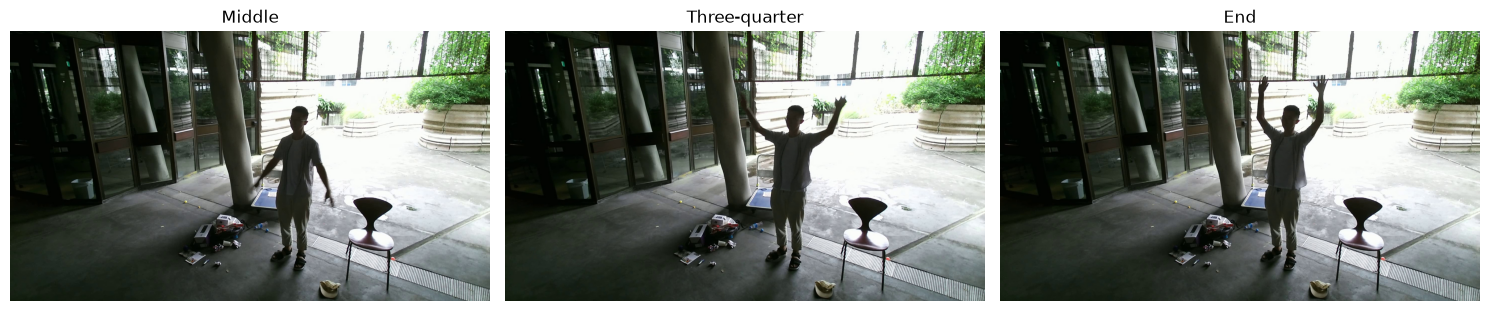

Middle Model Confidence: 99.99%
Middle Model Probabilities: tensor([[9.9990e-01, 2.3884e-05, 1.9901e-05, 5.3570e-05]])
Middle Model Prediction: Capitulate  = Class 1
---
Three-quarter Model Confidence: 99.95%
Three-quarter Model Probabilities: tensor([[9.9953e-01, 2.4715e-05, 7.6109e-05, 3.7141e-04]])
Three-quarter Model Prediction: Capitulate  = Class 1
---
End Model Confidence: 99.96%
End Model Probabilities: tensor([[9.9964e-01, 1.7428e-05, 1.7685e-05, 3.2090e-04]])
End Model Prediction: Capitulate  = Class 1
---
Overall Probabilities:  tensor([[2.9991e+00, 6.6027e-05, 1.1369e-04, 7.4588e-04]])
Overall Prediction:  Capitulate  = Class 1
True Label: class1


In [12]:
#random.seed(1)
def three_model_classifier(device, video_name="random", display_on = True):

    class_names = ["Capitulate  = Class 1", "Clapping = Class 2", "Cross Arms = Class 3", "Hand Waving = Class 4"]
    # use same transform configuration
    transform = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
    
    overall_probs = torch.Tensor([0,0,0,0])

    if video_name == "random":
        # choose random frame from test file
        random_frame = random.choice(list(Path("data/three_quarter_frame/test").glob("class*/*.jpg")))
        # get video name
        video_name = random_frame.name.partition("rgb")[0] + "rgb"

    # find frames 
    middle_path = next(Path("data/middle_frame/").rglob(f"{video_name}_ending.jpg"), None)
    three_quarter_path = next(Path("data/three_quarter_frame/").rglob(f"{video_name}_ending.jpg"), None)
    end_path = next(Path("data/end_frame/").rglob(f"{video_name}_ending.jpg"), None)

    paths = [
                ("Middle", middle_path),
                ("Three-quarter", three_quarter_path),
                ("End", end_path)
            ]
    
    # find true label
    true_label = three_quarter_path.parent.name

    # display frames
    if display_on:
        _, axes = plt.subplots(1, 3,figsize=(15, 5))
        
        for ax, (title, path) in zip(axes, paths):
            image = Image.open(path).convert("RGB")
            ax.imshow(image)
            ax.set_title(title)
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    # get predictions
    for (title,path), model_path in zip(paths, ["model_middle_", "model_three_quarter_", "model_end_"]):
        # transform image
        image = Image.open(path).convert("RGB")
        frame = transform(image).unsqueeze(0).to(device)

        # get model
        model = resnet_model.to(device)
        checkpoint = torch.load(f"checkpoints/{model_path}checkpoint.pth",map_location=device)
        model.load_state_dict(checkpoint[f"{model_path}state_dict"])
        model = model.to(device)
        model.eval()

        with torch.no_grad():
            output = model(frame)
            probabilities = torch.softmax(output, dim=1)
            confidence = probabilities[0, torch.argmax(probabilities, dim=1).item()].item()
            overall_probs = torch.add(overall_probs, probabilities)

        if display_on:
            print(f"{title} Model Confidence: {confidence:.2%}")
            print(f"{title} Model Probabilities: {probabilities}")
            print(f"{title} Model Prediction: {class_names[torch.argmax(probabilities, dim=1).item()]}")
            print("---")
    if display_on:
        print("Overall Probabilities: ", overall_probs)
        print("Overall Prediction: ", class_names[torch.argmax(overall_probs, dim=1).item()])
        print("True Label:", true_label)
    return torch.argmax(overall_probs, dim=1).item(), true_label

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
pred, _ = three_model_classifier(device, video_name="random", display_on=True)

### Evaluation of 3-Model-Classifier

In [35]:
def evaluate_3_model():

    # track labels and predictions
    true_labels = []
    preds = []

    # get all test video names
    test_dir = Path("data/end_frame/test")
    video_names = set(
        video.name.partition("rgb")[0] + "rgb"
        for class_dir in test_dir.iterdir()
        if class_dir.is_dir()
        for video in class_dir.iterdir()
        if video.is_file())

    for video_name in video_names:
        pred, true_label = three_model_classifier(device, video_name=video_name, display_on = False)

        true_labels.append(int(true_label.strip(string.ascii_letters))-1)
        preds.append(pred)

    overall_accuracy = accuracy_score(true_labels, preds)
    print(f"Overall Accuracy: {overall_accuracy:.4f}")
    #print(classification_report(true_labels, preds))

    report = classification_report(
        true_labels,
        preds,
        output_dict=True
    )

    class_accuracy = {
        f"class{i+1}": report[str(i)]["precision"]
        for i in range(4)
    }
    print(class_accuracy)
    return overall_accuracy, class_accuracy


acc_3_model, acc_classes_3_model = evaluate_3_model()

Overall Accuracy: 0.6928
{'class1': 0.9794520547945206, 'class2': 0.5704225352112676, 'class3': 0.6, 'class4': 0.6173913043478261}


## Model Comparison: Experiment 1 & 2

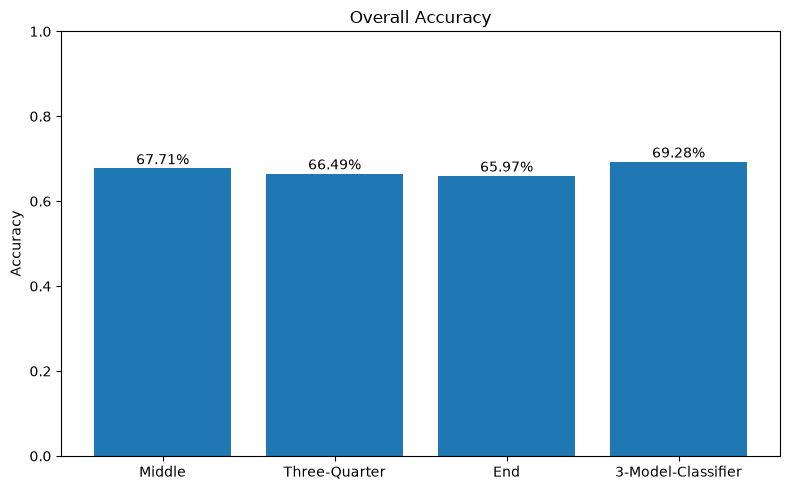

In [36]:
models = ["Middle","Three-Quarter","End", "3-Model-Classifier"]
total_acc = [
    acc_total_middle,
    acc_total_three_quarter,
    acc_total_end,
    acc_3_model
]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, total_acc)

plt.ylabel("Accuracy")
plt.title("Overall Accuracy")
plt.ylim(0, 1)

# Add values above bars
for bar, acc in zip(bars, total_acc):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{acc:.2%}",
        ha="center"
    )

plt.tight_layout()
plt.show()

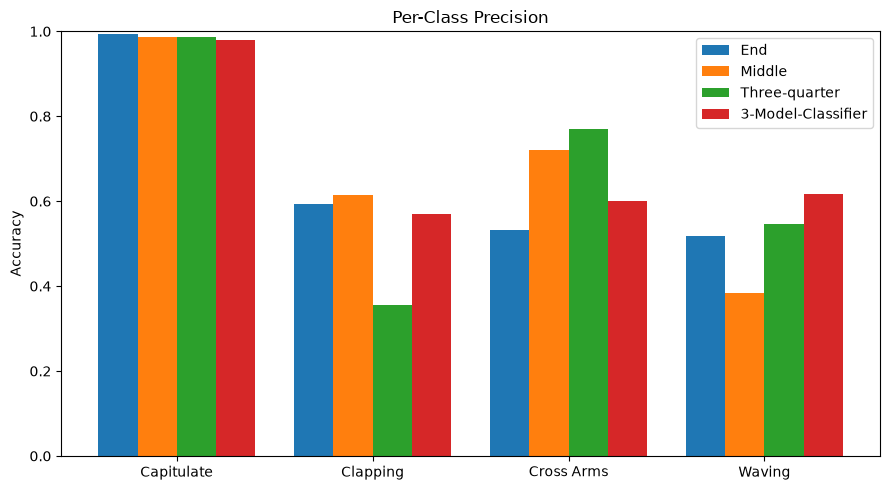

In [37]:
# plot per class accuracies
classes = list(acc_classes_end.keys())
x = np.arange(len(classes))
width = 0.2

plt.figure(figsize=(9, 5))

plt.bar(x - 1.5 * width,[acc_classes_end[c] for c in classes], width, label="End")
plt.bar(x - 0.5 * width,[acc_classes_middle[c] for c in classes], width, label="Middle")
plt.bar(x + 0.5 * width, [acc_classes_three_quarter[c] for c in classes], width, label="Three-quarter")
plt.bar(x + 1.5 * width, [acc_classes_3_model[c] for c in classes], width, label="3-Model-Classifier")

plt.xticks(x, ["Capitulate", "Clapping", "Cross Arms", "Waving"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Per-Class Precision")
plt.legend()
plt.tight_layout()
plt.show()

## Hyperparameter Tuning - Model 1

In [ ]:
def objective(trial):
    # Hyperparameters to search
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float(
        "weight_decay", 1e-6, 1e-2, log=True
    )
    optimizer_name = trial.suggest_categorical(
        "optimizer", ["SGD", "Adam"]
    )

    # Fresh pretrained model for every trial
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)
    model.fc = torch.nn.Linear(model.fc.in_features, 4)
    model = model.to(device)

    # Only train FC
    if optimizer_name == "SGD":
        momentum = trial.suggest_float("momentum", 0.8, 0.99)

        optimizer = torch.optim.SGD(
            model.fc.parameters(),
            lr=lr,
            momentum=momentum,
            weight_decay=weight_decay
        )

    else:
        optimizer = torch.optim.Adam(
            model.fc.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

    criterion = torch.nn.CrossEntropyLoss()

    # Train
    epochs = 5
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader_three_quarter:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
        print("Epoch: ", epoch)

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader_three_quarter:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    val_accuracy = correct / total

    return val_accuracy

if False:
    study = optuna.create_study(direction="maximize")

    study.optimize(
        objective,
        n_trials=10
    )

    print("Best validation accuracy:", study.best_value)
    print("Best hyperparameters:")
    print(study.best_params)

Best validation accuracy: 0.6824561403508772
Best hyperparameters:
{'lr': 0.0035562602273362834, 'weight_decay': 0.006032473823690534, 'optimizer': 'SGD', 'momentum': 0.8542568465008153}

### Model 5: Best Hyper-Parameter + Unfreeze ResNet18 Layer 4

In [ ]:
# load pretrained model
weights = ResNet18_Weights.DEFAULT
resnet_model = resnet18(weights=weights)

# modify last layer to 4 classes
resnet_model.fc = torch.nn.Linear(resnet_model.fc.in_features, 4)

# Freeze everything
for param in resnet_model.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

# unfreeze classifier
for param in resnet_model.fc.parameters():
    param.requires_grad = True

# define loss function and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD([
    {"params": resnet_model.layer4.parameters(), "lr": 1e-5},
    {"params": resnet_model.fc.parameters(), "lr": 0.003},
], momentum=0.85, weight_decay=0.006)

model_layer4 = resnet_model.to(device)

if False: # set to True to train model 
    # train model
    train(model_layer4, train_loader_three_quarter, val_loader_three_quarter, criterion, optimizer, num_epochs=10)

    # save checkpoint of model
    checkpoint = {
        "model_layer4_state_dict": model_three_quarter.state_dict(),
        "optimizer_model_layer4_state_dict": optimizer.state_dict(),
        "epoch": 10,
    }

    torch.save(
        checkpoint,
        "checkpoints/model_layer_checkpoint.pth"
    )

## Experiment 3: GRU

### Model 6: ResNet18 Model + GRU

In [15]:
class GRU_model(nn.Module):
    def __init__(self, num_classes=4):
        super(GRU_model, self).__init__()
        # load pretrained model
        resnet_model = resnet18(weights=ResNet18_Weights.DEFAULT)

        # remove last fc layer
        self.feature_extractor = nn.Sequential(*list(resnet_model.children())[:-1])

        # freeze ResNet
        for param in self.feature_extractor.parameters():
            param.requires_grad = False

        # GRU
        self.gru = nn.GRU(input_size=512, hidden_size=128, batch_first=True)

        # final classifier
        self.fc = nn.Linear(128, num_classes) 


    def forward(self,x):
        batch_size, seq_len, channels, height, width = x.size()

        # use ResNet for each picture in the sequence
        x = x.view(batch_size * seq_len, channels, height, width)

        #extract features with resnet
        with torch.no_grad(): 
            features = self.feature_extractor(x)

        # bring features into right sequential form
        features = torch.flatten(features, 1)
        features = features.view(batch_size, seq_len, 512)

        #process features with gru
        _, hn = self.gru(features)

        last_hidden_state = hn[-1]

        #classify
        output = self.fc(last_hidden_state)
        return output

### Load 8-frames-per-video dataset

In [ ]:
# load dataset
class VideoDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe 
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        video_folder = os.path.join(self.root_dir, row['frame_dir'] )

        video_class = int(row['class_id']) 

        img_sequence = sorted(os.listdir(video_folder))


        frames = []
        for img_name in img_sequence:
            img_path = os.path.join(video_folder, img_name)
            image = Image.open(img_path).convert('RGB') # to make 100% sure
            if self.transform:
                image = self.transform(image)
            frames.append(image)

        return torch.stack(frames), video_class

# define paths
DATASET_PATH = Path(r"data\video_frames_data")
CSV_PATH = DATASET_PATH / "metadata.csv"

# load CSV
full_df = pd.read_csv(CSV_PATH)

# normalize split names
full_df['split'] = full_df['split'].str.strip().str.lower()

# load training data
train_df = full_df[full_df['split'] == 'train'].reset_index(drop=True)

# load validation data
val_df = full_df[full_df['split'] == 'val'].reset_index(drop=True)

# Dataset and Loader
train_dataset = VideoDataset(dataframe=train_df, root_dir=DATASET_PATH, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataset = VideoDataset(dataframe=val_df, root_dir=DATASET_PATH, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

### Training Loop for GRU Model

In [40]:
# training loop 
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs):

    for epoch in range(num_epochs):
        # training mode
        model.train()

        running_loss = 0.0
        running_corrects = 0

        # iterate training data loader
        for inputs, labels in train_loader:
            # put to device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # reset gradients 
            optimizer.zero_grad()

            # forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            # backward pass
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        # epoch training loss and accuracy 
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = running_corrects.float() / len(train_loader.dataset)


        ## Evaluation
        model.eval()
        running_loss = 0.0
        running_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # forward pass
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

        # validation loss and accuracy 
        val_loss = running_loss / len(val_loader.dataset)
        val_acc = running_corrects.float() / len(val_loader.dataset)

        print(f'Epoch [{epoch+1}/{num_epochs}], train loss: {train_loss:.4f}, train acc: {train_acc:.4f}, val loss: {val_loss:.4f}, val acc: {val_acc:.4f} \n')

In [41]:
# train model
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
gru_model = GRU_model(num_classes=4).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, gru_model.parameters()), lr=0.001) 

if False:
    train(gru_model, train_loader, val_loader, criterion, optimizer, num_epochs=20)

    # save checkpoint of model
    checkpoint = {
        "GRU_model_state_dict": gru_model.state_dict(),
        "optimizer_GRU_model_state_dict": optimizer.state_dict(),
        "epoch": 20,
    }

    torch.save(
        checkpoint,
        "checkpoints/GRU_model_checkpoint.pth"
    )

### Evaluation for GRU Model

In [42]:
def evaluate_GRU_model(model, loader, device):
    model.eval()

    true_labels = []
    preds = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            true_labels.extend(labels.cpu().numpy())
            preds.extend(predicted.cpu().numpy())

    print(f"Overall Accuracy: {accuracy_score(true_labels, preds):.4f}")
    print(classification_report(true_labels, preds))
    
    report = classification_report(true_labels, preds, output_dict=True)
    return accuracy_score(true_labels, preds), {f"class{i+1}": report[str(i)]["recall"] for i in range(4) if str(i) in report}

In [44]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

#load model
gru_model = GRU_model(num_classes=4).to(device)
checkpoint = torch.load("checkpoints/Experiment3_checkpoint.pth", map_location=device)
gru_model.load_state_dict(checkpoint["Experiment3_state_dict"])

acc_GRU_model, acc_classes_GRU_model = evaluate_GRU_model(gru_model, val_loader, device)

Overall Accuracy: 0.6211
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       144
           1       0.44      0.47      0.45       142
           2       0.68      0.35      0.46       142
           3       0.47      0.67      0.55       142

    accuracy                           0.62       570
   macro avg       0.65      0.62      0.62       570
weighted avg       0.65      0.62      0.62       570



# Examples for Simon Says

In [47]:
def extract_frames(video_path):
    video = cv2.VideoCapture(str(video_path))
    total_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
    output_dir = video_path.parent / video_path.stem
    output_dir.mkdir(parents=True, exist_ok=True)

    # sample 8 frames
    indices = np.linspace(0, total_frames - 1, 8, dtype=int)
    saved_frames = 0

    for idx in indices:
        video.set(cv2.CAP_PROP_POS_FRAMES, idx)
        _, frame = video.read()

        frame = cv2.resize(
            frame,
            (224, 224),
            interpolation=cv2.INTER_AREA)

        output_path = output_dir / f"frame_{saved_frames + 1:05d}.jpg"
        cv2.imwrite(str(output_path), frame, [cv2.IMWRITE_JPEG_QUALITY, 95])
        saved_frames += 1
    video.release()

    return output_dir

def classify_example(video_path):
    display(
        Video(
            str(video_path),
            embed=True,
            width=200
        )
    )
    frames_path = extract_frames(video_path)
    class_names = ["Capitulate  = Class 1", "Clapping = Class 2", "Cross Arms = Class 3", "Hand Waving = Class 4"]

    # load model
    model = GRU_model(num_classes=4).to(device)
    checkpoint = torch.load("checkpoints/Experiment3_checkpoint.pth", map_location=device)
    model.load_state_dict(checkpoint["Experiment3_state_dict"])

    frames = []
    for img_path in sorted(frames_path.glob("*.jpg")):
        image = Image.open(img_path).convert("RGB")
        image = transform(image)
        frames.append(image)

    frames = torch.stack(frames).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(frames)
        probabilities = torch.softmax(output, dim=1)
    print(f"Model Prediction: {class_names[torch.argmax(probabilities, dim=1).item()]}")

    return 

classify_example(Path("data/example_data/gwen_class4.mp4"))

Model Prediction: Hand Waving = Class 4
